# ISL Model Training

**Goal:** Train a classifier for Indian Sign Language (ISL) recognition.

Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
from datetime import datetime
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

## 1. Load ISL Dataset

In [15]:
 # processed Kaggle or custom dataset
data_path = '../data/raw/isl_dataset.npz' 

data = np.load(data_path, allow_pickle=True)

X = data['features']
y = data['labels']

# Class names
if 'class_names' in data:
    class_names = data['class_names'].tolist()
    ISL_CLASSES = {i: name for i, name in enumerate(class_names)}
else:
    ISL_CLASSES = {i: chr(65 + i) for i in range(26)}

print("Dataset Loaded")
print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("Number of classes:", len(ISL_CLASSES))

Dataset Loaded
Features shape: (507, 57)
Labels shape: (507,)
Number of classes: 23


## 2. Dataset Analysis

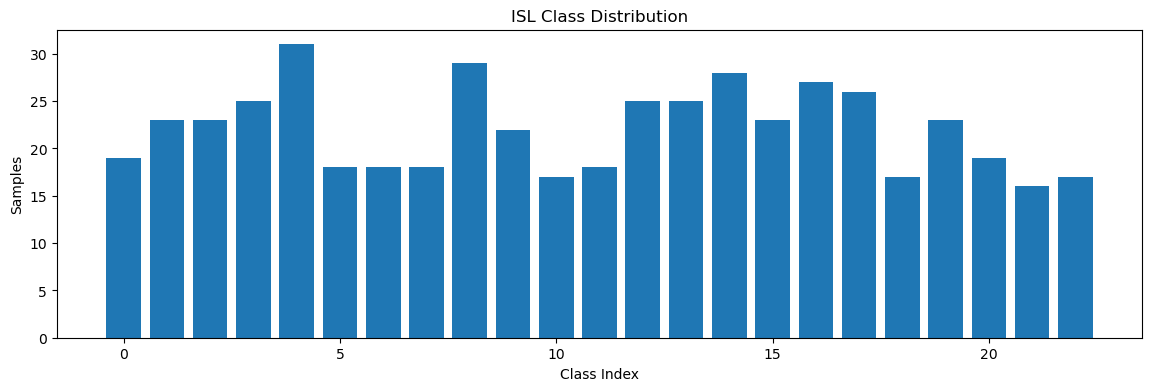

Min samples per class: 16
Max samples per class: 31
Imbalance ratio: 1.94


In [20]:
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(14, 4))
plt.bar(unique, counts)
plt.xlabel("Class Index")
plt.ylabel("Samples")
plt.title("ISL Class Distribution")
plt.show()

imbalance_ratio = counts.max() / counts.min()

print("Min samples per class:", counts.min())
print("Max samples per class:", counts.max())
print("Imbalance ratio:", round(imbalance_ratio, 2))

if imbalance_ratio > 3:
    print("Class imbalance detected")

## 3. Train-Test Split & Scaling

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 405
Test samples: 102


## 4. Model Training & Evaluation

In [26]:
models = {
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        probability=True,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ),
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}

In [28]:
results = {}

print("Training models\n")

for name, model in models.items():
    print(f" {name}")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv)

    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1": f1,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "y_pred": y_pred
    }

    print(f"   Accuracy: {acc:.4f}")
    print(f"   F1-score: {f1:.4f}")
    print(f"   CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}\n")

Training models

 SVM (RBF)
   Accuracy: 0.7059
   F1-score: 0.7001
   CV: 0.7210 ± 0.0354

 Random Forest
   Accuracy: 0.7549
   F1-score: 0.7423
   CV: 0.7309 ± 0.0121

 Gradient Boosting
   Accuracy: 0.6765
   F1-score: 0.6638
   CV: 0.6099 ± 0.0555

 MLP Neural Network


/opt/anaconda3/envs/gesture-recognition/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/opt/anaconda3/envs/gesture-recognition/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/opt/anaconda3/envs/gesture-recognition/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/opt/anaconda3/envs/ge

   Accuracy: 0.6667
   F1-score: 0.6524
   CV: 0.6222 ± 0.0759



/opt/anaconda3/envs/gesture-recognition/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/opt/anaconda3/envs/gesture-recognition/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/opt/anaconda3/envs/gesture-recognition/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/opt/anaconda3/envs/ge

## 5. Model Comparison

,Model,Accuracy,F1-Score,CV Mean
0,SVM (RBF),0.705882,0.700063,0.720988
1,Random Forest,0.754902,0.742271,0.730864
2,Gradient Boosting,0.676471,0.663798,0.609877
3,MLP Neural Network,0.666667,0.652369,0.622222


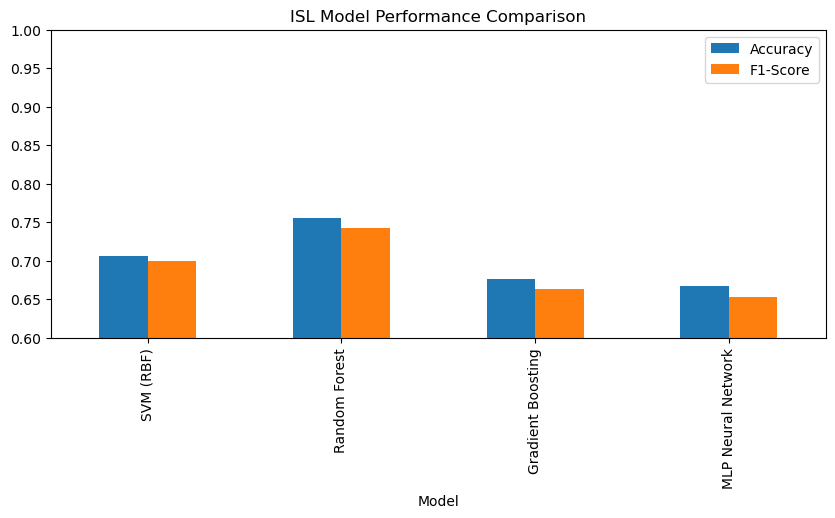

In [30]:
comparison_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": [r["accuracy"] for r in results.values()],
    "F1-Score": [r["f1"] for r in results.values()],
    "CV Mean": [r["cv_mean"] for r in results.values()]
})

display(comparison_df)

comparison_df.plot(
    x="Model",
    y=["Accuracy", "F1-Score"],
    kind="bar",
    figsize=(10,4),
    ylim=(0.6,1.0)
)
plt.title("ISL Model Performance Comparison")
plt.show()

## 6. Best Model & Evaluation

In [34]:
best_model_name = max(results, key=lambda x: results[x]["accuracy"])
best_model = results[best_model_name]["model"]
y_pred = results[best_model_name]["y_pred"]

print("Best Model:", best_model_name)
print(classification_report(y_test, y_pred, digits=4))

Best Model: Random Forest
              precision    recall  f1-score   support

           0     1.0000    0.2500    0.4000         4
           1     0.6000    0.6000    0.6000         5
           2     1.0000    1.0000    1.0000         5
           3     0.8000    0.8000    0.8000         5
           4     0.8333    0.8333    0.8333         6
           5     0.6667    1.0000    0.8000         4
           6     0.6667    0.6667    0.6667         3
           7     1.0000    0.5000    0.6667         4
           8     0.6250    0.8333    0.7143         6
           9     1.0000    1.0000    1.0000         4
          10     0.5000    0.3333    0.4000         3
          11     0.5000    0.2500    0.3333         4
          12     0.8000    0.8000    0.8000         5
          13     0.6667    0.8000    0.7273         5
          14     0.6000    0.5000    0.5455         6
          15     1.0000    1.0000    1.0000         5
          16     0.8333    1.0000    0.9091         5
 

## 7. Confusion Matrix

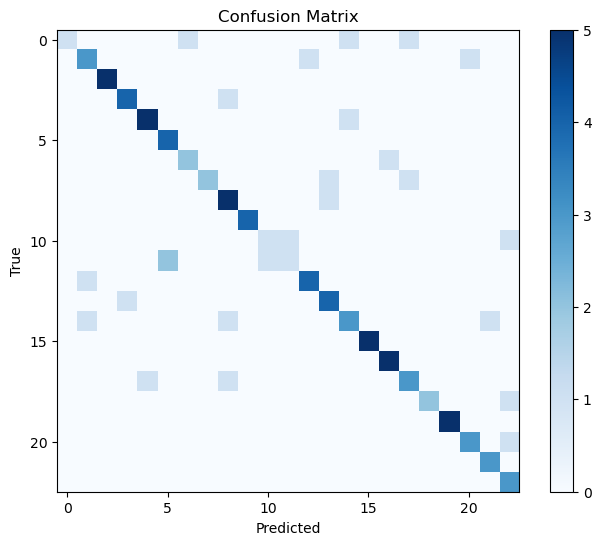

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## 8. Save Final ISL Model

In [40]:
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/isl_gesture_classifier.pkl')
joblib.dump(scaler, '../models/isl_scaler.pkl')

metadata = {
    "model": best_model_name,
    "accuracy": results[best_model_name]["accuracy"],
    "f1_score": results[best_model_name]["f1"],
    "num_classes": len(ISL_CLASSES),
    "trained_on": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('../models/isl_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Model, scaler & metadata saved")

Model, scaler & metadata saved
